## Exercicio 1

In [33]:
## imports

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from IPython.display import display

In [34]:
x_img = cv2.imread("lena.tif")
cv2.imshow(" OriginalImage " , x_img )
print(x_img.dtype)
print(x_img.shape)
cv2.waitKey(0)
cv2.destroyAllWindows()

uint8
(512, 512, 3)


#### No caso do exercicio 1, a função dtype é utilizada para sabermos que tipo de dados estão na imagem, neste caso sao uint de 8 bits. A função shape é para informar das dimensões da imagem (512,512,3) onde (512,512) indicam as dimensoes em pixeis e o 3 representa as componentes das cores, RBG.


## Exercicio 2

Tamanho do original (lena.tif):  786572 bytes
Tamanho do file1.jpg:  44124 bytes
Tamanho do file2.jpg:  9566 bytes
Taxa de compressão (original/file1): 17.83
Taxa de compressão (original/file2): 82.23
Q80 -> SNR (dBs):  28.468534958720454
Q80 -> PSNR (dBs):  33.606097256534746
Q10 -> SNR (dBs):  22.391956905436455
Q10 -> PSNR (dBs):  27.529519203250743


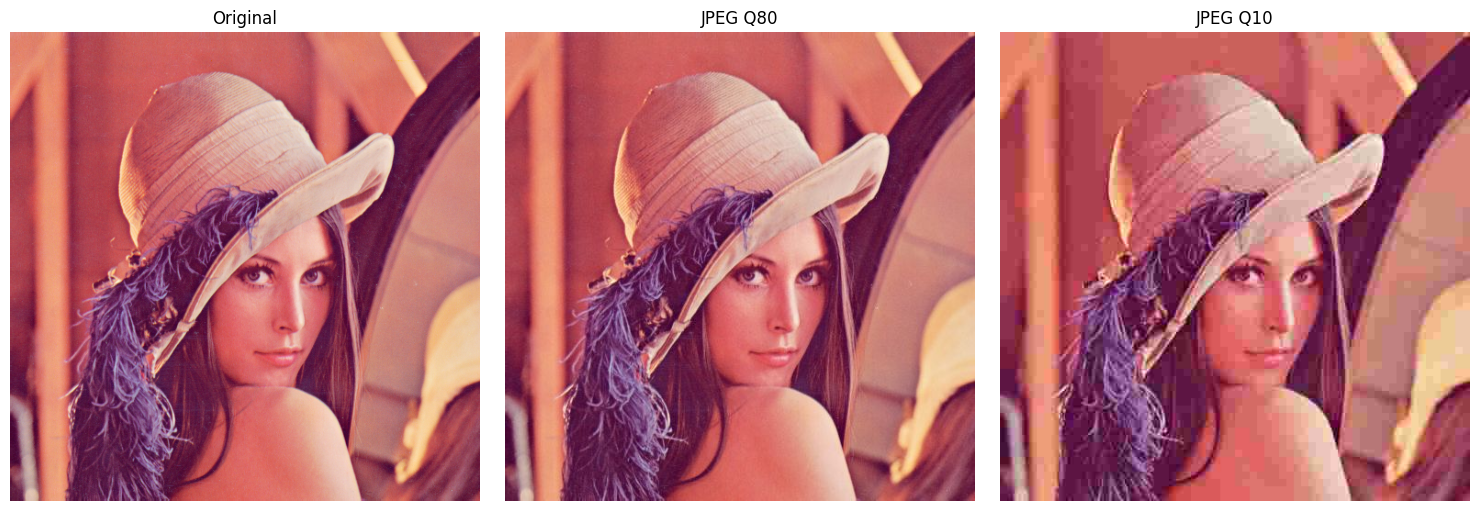

In [35]:
x_img = cv2.imread("lena.tif")

cv2.imwrite("img/file1.jpg", x_img, ( cv2.IMWRITE_JPEG_QUALITY, 80))
cv2.imwrite("img/file2.jpg", x_img, ( cv2.IMWRITE_JPEG_QUALITY, 10))

x_img1 = cv2.imread("img/file1.jpg")
x_img2 = cv2.imread("img/file2.jpg")

size_org = os.path.getsize("lena.tif")
size_img1 = os.path.getsize("img/file1.jpg")
size_img2 = os.path.getsize("img/file2.jpg")
print('Tamanho do original (lena.tif): ', size_org, 'bytes')
print('Tamanho do file1.jpg: ', size_img1, 'bytes')
print('Tamanho do file2.jpg: ', size_img2, 'bytes')

tc1 = size_org / size_img1
tc2 = size_org / size_img2
print('Taxa de compressão (original/file1): %.2f' % tc1)
print('Taxa de compressão (original/file2): %.2f' % tc2)

x_float = x_img*1.
x_img1_float = x_img1*1.
x_img2_float = x_img2*1.

Porg = np.mean(x_float**2)

Perr1 = np.mean((x_float - x_img1_float)**2)
SNR1 = 10*np.log10(Porg/Perr1)
pSNR1 = 10*np.log10(255**2/Perr1)

Perr2 = np.mean((x_float - x_img2_float)**2)
SNR2 = 10*np.log10(Porg/Perr2)
pSNR2 = 10*np.log10(255**2/Perr2)

print('Q80 -> SNR (dBs): ', SNR1)
print('Q80 -> PSNR (dBs): ', pSNR1)
print('Q10 -> SNR (dBs): ', SNR2)
print('Q10 -> PSNR (dBs): ', pSNR2)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(x_img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(x_img1, cv2.COLOR_BGR2RGB))
plt.title('JPEG Q80')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(x_img2, cv2.COLOR_BGR2RGB))
plt.title('JPEG Q10')
plt.axis('off')

plt.tight_layout()
plt.show()

## Exercicio 3

In [1]:
x_img = cv2.imread("lena.tif")
x_img_g = cv2.cvtColor(x_img,cv2.COLOR_BGR2GRAY)
cv2.imshow("GrayImage",x_img_g)
cv2.waitKey(0)
cv2.destroyAllWindows()
qual = 1
cv2.imwrite('img/file3_%d.bmp' % qual, x_img_g)

Size_org= os.path.getsize('lena.tif')
Size_jpg = os.path.getsize('img/file3_%d.bmp'%qual)
print('Tamanho original: ', Size_org)
print('Tamanho da imagem bmp: ', Size_jpg)

NameError: name 'cv2' is not defined

## Exercicio 4

Numero de niveis diferentes de cinzento: 215


C:\Users\helen\AppData\Local\Temp\ipykernel_5760\738917996.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(x_img_g.ravel(),256,[0,256])


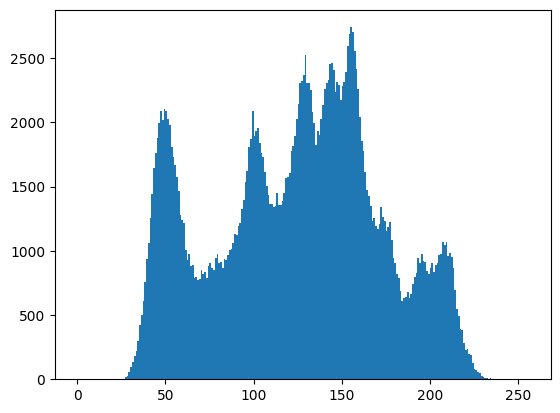

In [ ]:
plt.hist(x_img_g.ravel(),256,[0,256])
niveis = np.unique(x_img_g).size
print("Numero de niveis diferentes de cinzento:", niveis)

## Exercicio 5

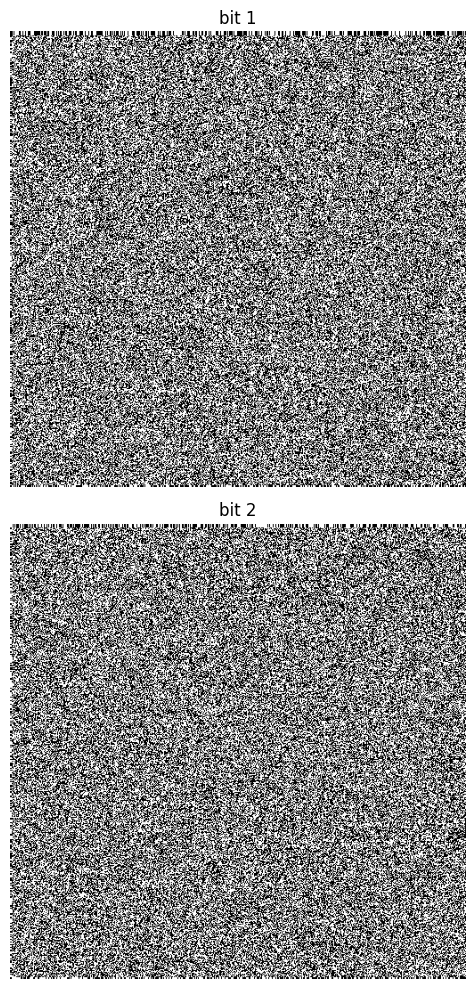

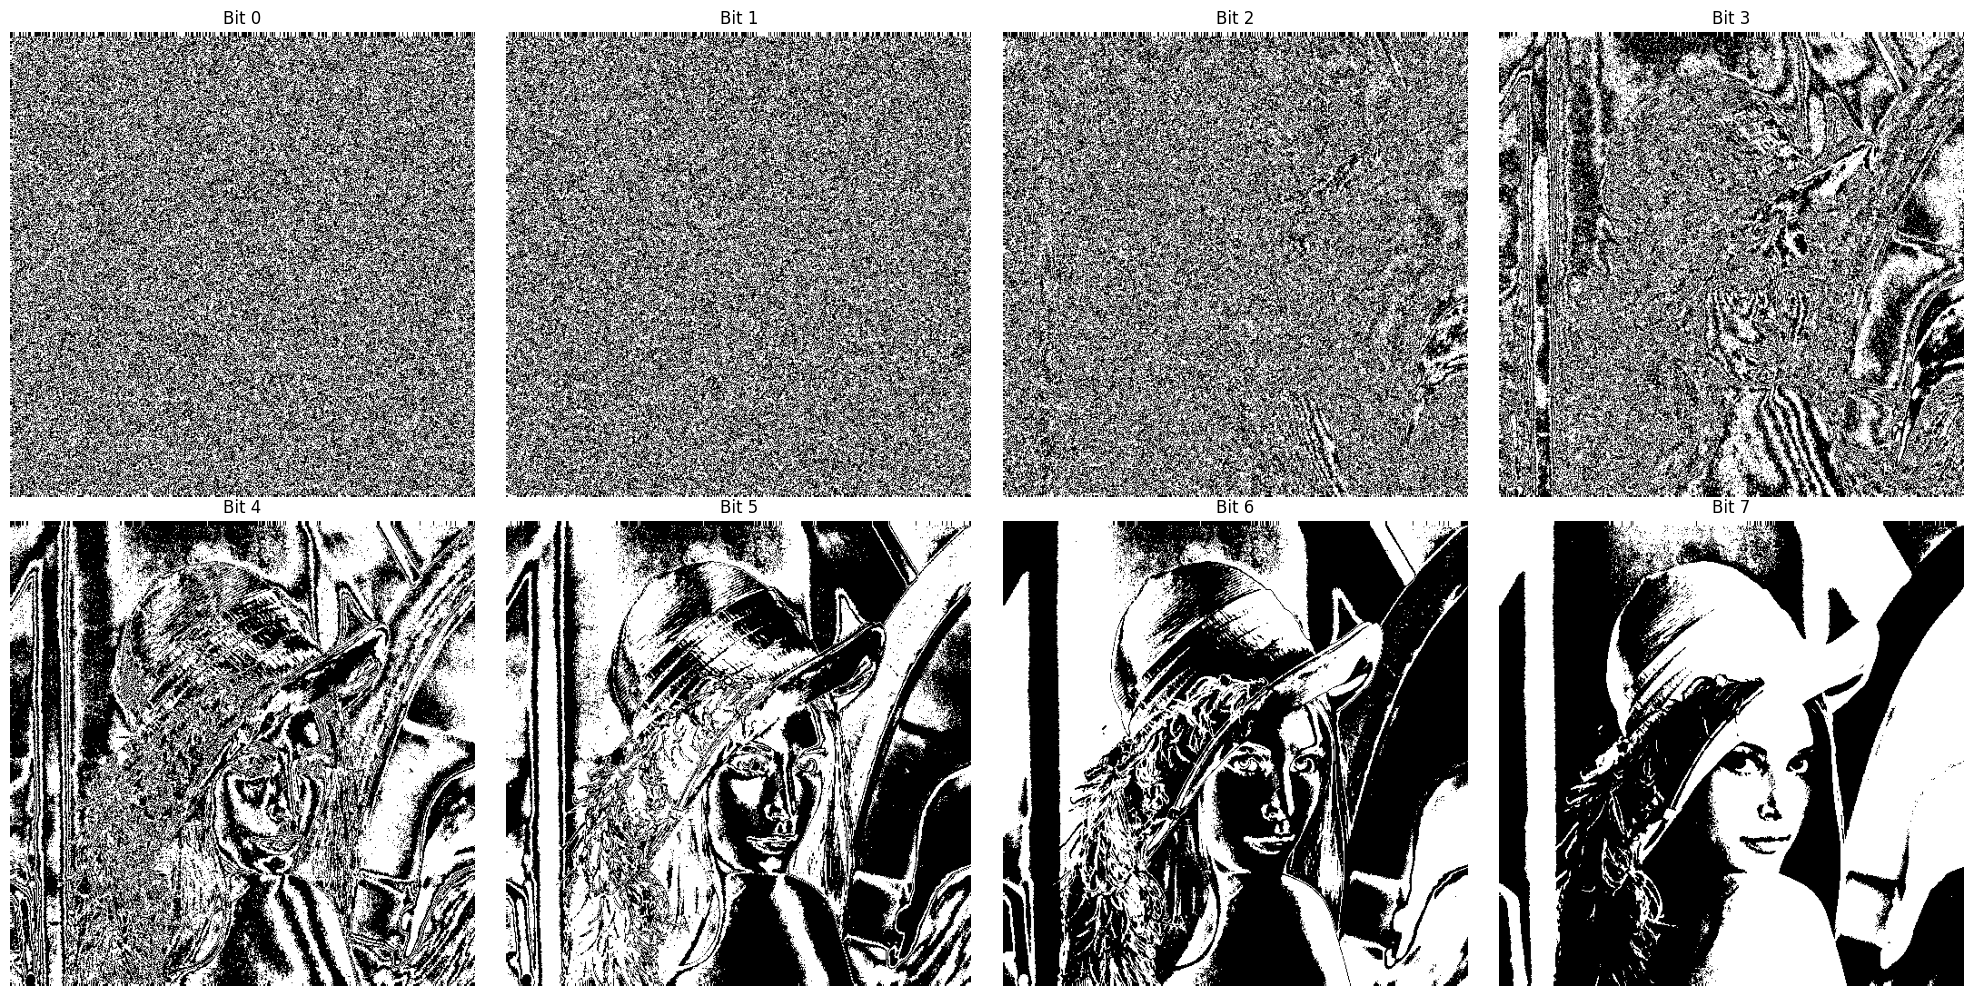

In [ ]:
# Código original para mostrar apenas os bits 1 e 2
if 'x_img_g' not in globals():
    if 'x_img' not in globals():
        x_img = cv2.imread('lena.tif')
    x_img_g = cv2.cvtColor(x_img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(20, 10))
plt.subplot(211)
I1 = (x_img_g % 2) * 255
plt.imshow(I1, cmap="gray")
plt.axis("off")
plt.title("bit 1")
plt.subplot(212)
I2 = ((x_img_g >> 1) % 2) * 255
plt.imshow(I2, cmap="gray")
plt.axis("off")
plt.title("bit 2")
plt.tight_layout()
plt.show()

# Mostrar todos os 8 bits em subplots
plt.figure(figsize=(20, 10))
for i in range(8):
    bit_img = ((x_img_g >> i) & 1) * 255
    plt.subplot(2, 4, i+1)
    plt.imshow(bit_img, cmap='gray')
    plt.title(f'Bit {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Exercicio 6

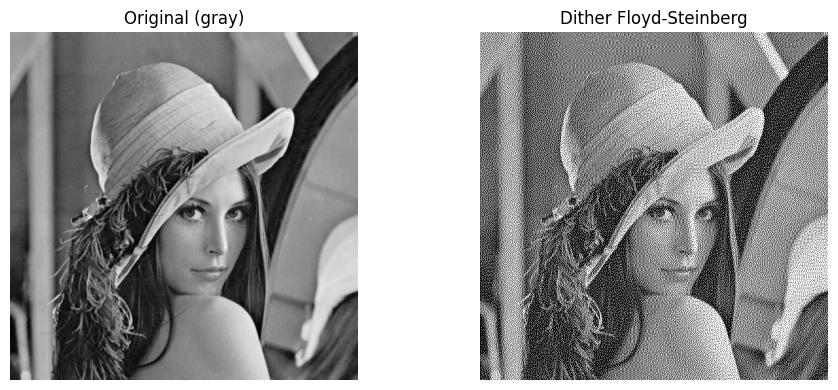

In [ ]:
def find_closest_palette_color(oldpixel):
    return 255.0 if oldpixel >= 128.0 else 0.0

def dither(x):
    pixels = x.astype(np.float32).copy()
    h, w = pixels.shape

    for y in range(h):
        for x in range(w):
            oldpixel = pixels[y, x]
            newpixel = find_closest_palette_color(oldpixel)
            pixels[y, x] = newpixel
            quant_error = oldpixel - newpixel

            if x + 1 < w:
                pixels[y, x + 1] = pixels[y, x + 1] + quant_error * 7.0 / 16.0
            if y + 1 < h and x - 1 >= 0:
                pixels[y + 1, x - 1] = pixels[y + 1, x - 1] + quant_error * 3.0 / 16.0
            if y + 1 < h:
                pixels[y + 1, x] = pixels[y + 1, x] + quant_error * 5.0 / 16.0
            if y + 1 < h and x + 1 < w:
                pixels[y + 1, x + 1] = pixels[y + 1, x + 1] + quant_error * 1.0 / 16.0

    return pixels.astype(np.uint8)

if 'x_img_g' not in globals():
    if 'x_img' not in globals():
        x_img = cv2.imread('lena.tif')
    x_img_g = cv2.cvtColor(x_img, cv2.COLOR_BGR2GRAY)

y = dither(x_img_g)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_img_g, cmap='gray')
plt.title('Original (gray)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(y, cmap='gray')
plt.title('Dither Floyd-Steinberg')
plt.axis('off')
plt.tight_layout()
plt.show()

## Exercicio 7

In [ ]:

def gravar_matriz_binaria(nome_ficheiro, matriz):
    h, w = matriz.shape
    bits = (matriz > 0).astype(np.uint8)
    packed = np.packbits(bits)
    with open(nome_ficheiro, 'wb') as f:
        np.array([h, w], dtype=np.uint32).tofile(f)
        packed.tofile(f)

if 'y' not in globals():
    raise ValueError("Execute primeiro o Exercício 6 para criar y.")

if 'x_img_g' not in globals():
    raise ValueError("Falta a imagem de referência x_img_g.")

ficheiro_inicial = 'img/y_raw.bin'
ficheiro_final = 'img/y_packed.bin'

y.astype(np.uint8).tofile(ficheiro_inicial)
gravar_matriz_binaria(ficheiro_final, y)

with open(ficheiro_final, 'rb') as f:
    h, w = np.fromfile(f, dtype=np.uint32, count=2)
    packed = np.fromfile(f, dtype=np.uint8)

bits = np.unpackbits(packed)[:h * w]
y_rec = (bits.reshape(h, w) * 255).astype(np.uint8)

size_inicial = os.path.getsize(ficheiro_inicial)
size_final = os.path.getsize(ficheiro_final)

tc = size_inicial / size_final

x_float = x_img_g * 1.
y_rec_float = y_rec * 1.

Porg = np.mean(x_float**2)
Perr = np.mean((x_float - y_rec_float)**2)

if Perr == 0:
    SNR = np.inf
    pSNR = np.inf
else:
    SNR = 10*np.log10(Porg/Perr)
    pSNR = 10*np.log10(255**2/Perr)

print('Tamanho do ficheiro inicial: ', size_inicial, 'bytes')
print('Tamanho do ficheiro final: ', size_final, 'bytes')
print('Taxa de compressão (inicial/final): %.2f' % tc)
print('SNR (dBs): ', SNR)
print('PSNR (dBs): ', pSNR)

Tamanho do ficheiro inicial:  262144 bytes
Tamanho do ficheiro final:  32776 bytes
Taxa de compressão (inicial/final): 8.00
SNR (dBs):  1.0492432084482375
PSNR (dBs):  6.705665423373192


## Exercicio 8

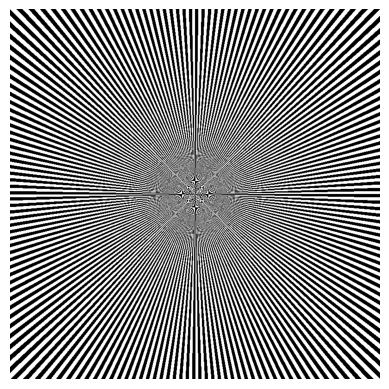

In [ ]:
# a imagem é de n*n, logo o centro da imagem é o pixel (n/2, n/2)
def imagem_setores(N, angulo_sector):
    
    img = np.zeros((N, N))

    cx = N // 2
    cy = N // 2

    for y in range(N):
        for x in range(N):

            dx = x - cx
            dy = y - cy

            ang = np.degrees(np.arctan2(dy, dx))

            if ang < 0:
                ang += 360

            sector = int(ang // angulo_sector)

            if sector % 2 == 0:
                img[y, x] = 0   # preto
            else:
                img[y, x] = 255 # branco
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

imagem_setores(800, 1)

## Exercicio 9
### alinea a.

Dimensoes da imagem: (283, 900)
Tipo dos elementos: uint8


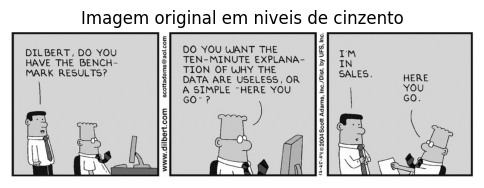

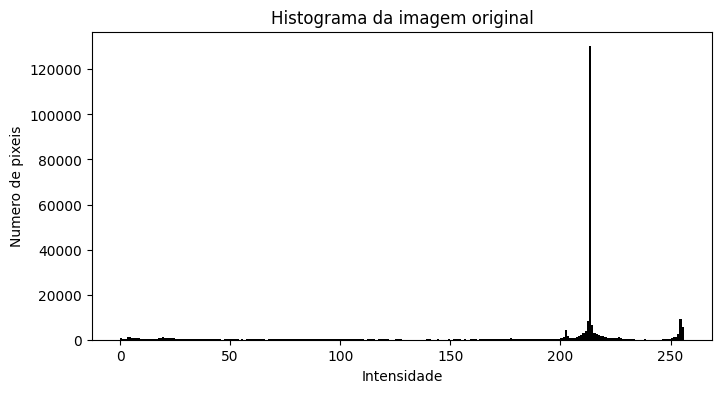

Valores unicos originais: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 

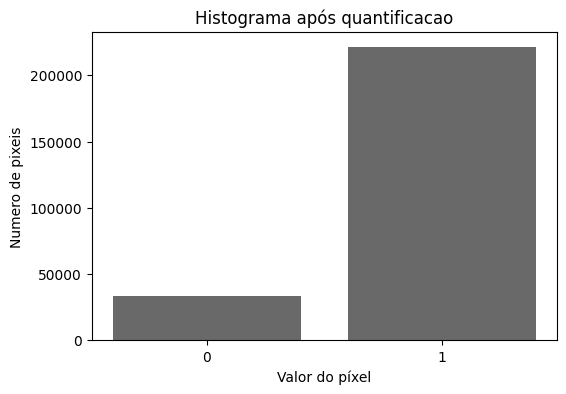

Valores unicos após reescalar [0,255]: [  0 255]


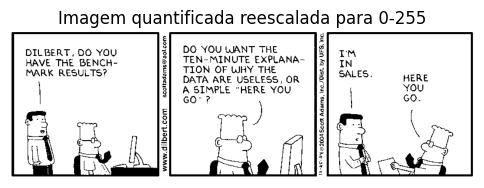

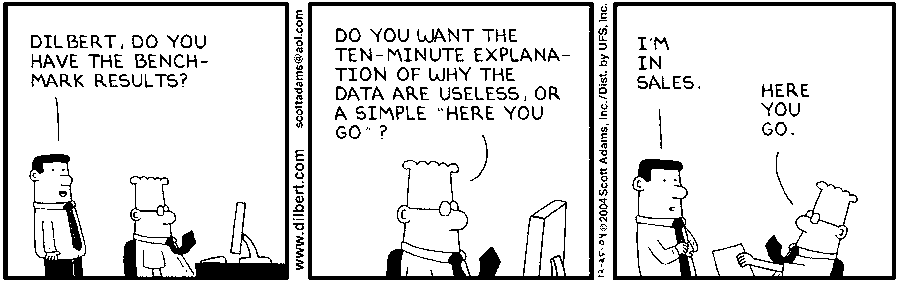

In [ ]:
imagem = cv2.imread('img/xpto3.jpeg', 0)

if imagem is None:
    raise FileNotFoundError('Nao foi possivel abrir img/xpto3.jpeg')

print('Dimensoes da imagem:', imagem.shape)
print('Tipo dos elementos:', imagem.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(imagem, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem original em niveis de cinzento')
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(imagem.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Histograma da imagem original')
plt.xlabel('Intensidade')
plt.ylabel('Numero de pixeis')
plt.show()

valores_unicos = np.unique(imagem)
print('Valores unicos originais:', valores_unicos)

imagem_01 = imagem.astype(np.float32) / 255.0
imagem_binaria_01 = (imagem_01 >= 0.5).astype(np.uint8)

print('Valores unicos após quantificacao [0,1]:', np.unique(imagem_binaria_01))

plt.figure(figsize=(6, 4))
plt.hist(imagem_binaria_01.ravel(), bins=[-0.5, 0.5, 1.5], color='dimgray', rwidth=0.8)
plt.xticks([0, 1])
plt.title('Histograma após quantificacao')
plt.xlabel('Valor do píxel')
plt.ylabel('Numero de pixeis')
plt.show()

imagem_binaria_255 = (imagem_binaria_01 * 255).astype(np.uint8)
print('Valores unicos após reescalar [0,255]:', np.unique(imagem_binaria_255))

plt.figure(figsize=(6, 6))
plt.imshow(imagem_binaria_255, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem quantificada reescalada para 0-255')
plt.axis('off')
plt.show()

display(Image.fromarray(imagem_binaria_255, mode='L'))

### alinea b.
#### i.

In [ ]:
def canal_ruidoso(imagem_binaria_01 , f):
    ruido = np.random.rand(*imagem_binaria_01 .shape) < f
    img_ruidosa = np.bitwise_xor(imagem_binaria_01 , ruido.astype(np.uint8))
    return img_ruidosa

def calcular_ber(img_original, img_ruidosa):
    erros = np.sum(img_original != img_ruidosa)
    total = img_original.size
    ber = erros / total
    return ber

# Exemplo de uso:
f_list = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
ber_list = []
imagens_ruidosas = []

for f in f_list:
    img_ruidosa = canal_ruidoso(imagem_binaria_01, f)
    ber = calcular_ber(imagem_binaria_01, img_ruidosa)
    ber_list.append(ber)
    imagens_ruidosas.append(img_ruidosa)
    print(f"f={f}: BER={ber:.4f}")

f=0.001: BER=0.0011
f=0.005: BER=0.0051
f=0.01: BER=0.0098
f=0.05: BER=0.0499
f=0.1: BER=0.1002
f=0.2: BER=0.2003
f=0.3: BER=0.2990
f=0.4: BER=0.4011
f=0.5: BER=0.4995


#### ii.

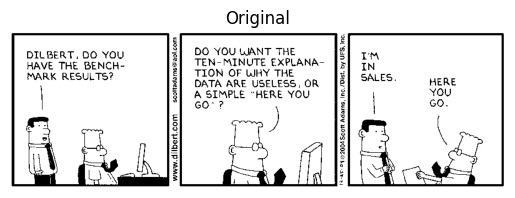

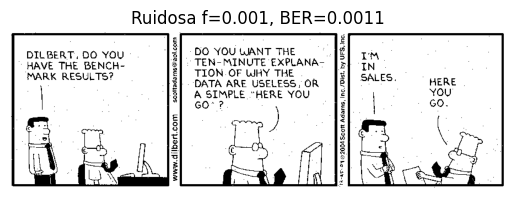

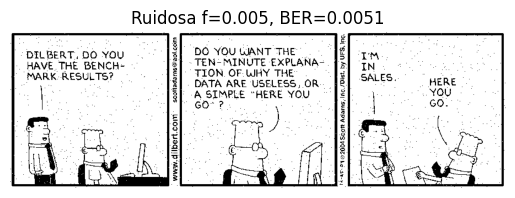

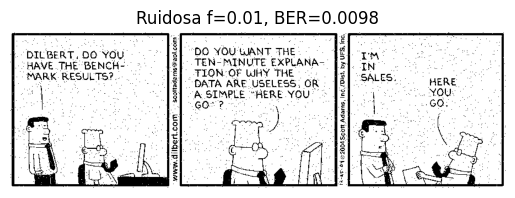

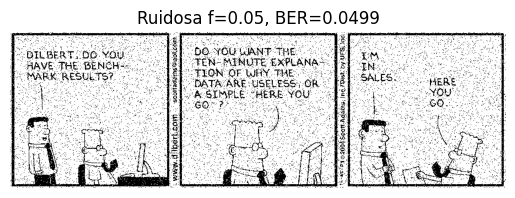

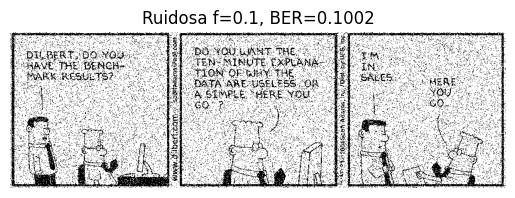

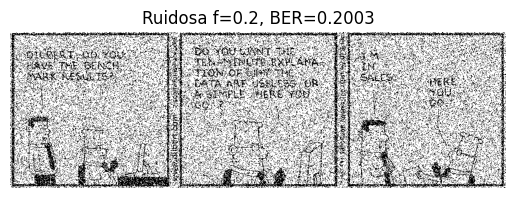

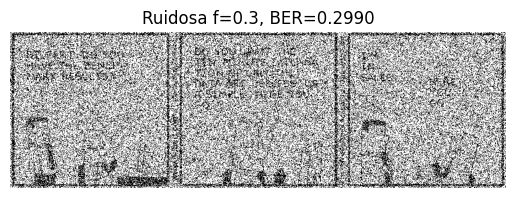

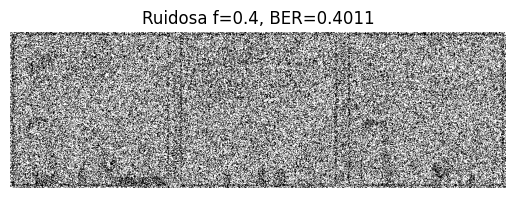

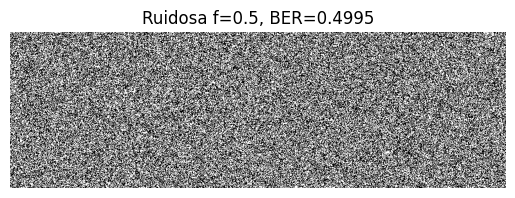

In [ ]:
def mostrar_imagem(img, titulo=''):
    img_uint8 = (img * 255).astype(np.uint8)
    plt.imshow(img_uint8, cmap='gray')
    plt.title(titulo)
    plt.axis('off')
    plt.show()

# Mostrar imagem original
mostrar_imagem(imagem_binaria_01, 'Original')

# Mostrar imagens ruidosas
for i, f in enumerate(f_list):
    mostrar_imagem(imagens_ruidosas[i], f'Ruidosa f={f}, BER={ber_list[i]:.4f}')

#### iii.

In [ ]:
def codificar_repeticao(imagem_binaria_01, N):
    return np.repeat(imagem_binaria_01, N, axis=1)

def decodificar_repeticao(img_codificada, N):
    blocos = img_codificada.reshape(img_codificada.shape[0], -1, N)
    img_decodificada = np.round(np.mean(blocos, axis=2)).astype(np.uint8)
    return img_decodificada

N_list = [3, 5, 7, 9, 11, 61]

for N in N_list:
    print(f"\nCódigo de repetição N={N}")
    img_codificada = codificar_repeticao(imagem_binaria_01, N)
    for i, f in enumerate(f_list):
        img_codificada_ruidosa = canal_ruidoso(img_codificada, f)
        img_decodificada = decodificar_repeticao(img_codificada_ruidosa, N)
        ber_corrigida = calcular_ber(imagem_binaria_01, img_decodificada)
        print(f"f={f}: BER após correção = {ber_corrigida:.4f}")
        # Para visualizar:
        # mostrar_imagem(img_decodificada, f'N={N}, f={f}, BER={ber_corrigida:.4f}')


Código de repetição N=3
f=0.001: BER após correção = 0.0000
f=0.005: BER após correção = 0.0001
f=0.01: BER após correção = 0.0003
f=0.05: BER após correção = 0.0075
f=0.1: BER após correção = 0.0282
f=0.2: BER após correção = 0.1033
f=0.3: BER após correção = 0.2153
f=0.4: BER após correção = 0.3513
f=0.5: BER após correção = 0.5014

Código de repetição N=5
f=0.001: BER após correção = 0.0000
f=0.005: BER após correção = 0.0000
f=0.01: BER após correção = 0.0000
f=0.05: BER após correção = 0.0012
f=0.1: BER após correção = 0.0083
f=0.2: BER após correção = 0.0573
f=0.3: BER após correção = 0.1640
f=0.4: BER após correção = 0.3167
f=0.5: BER após correção = 0.5000

Código de repetição N=7
f=0.001: BER após correção = 0.0000
f=0.005: BER após correção = 0.0000
f=0.01: BER após correção = 0.0000
f=0.05: BER após correção = 0.0002
f=0.1: BER após correção = 0.0027
f=0.2: BER após correção = 0.0337
f=0.3: BER após correção = 0.1269
f=0.4: BER após correção = 0.2886
f=0.5: BER após correçã

#### iV.


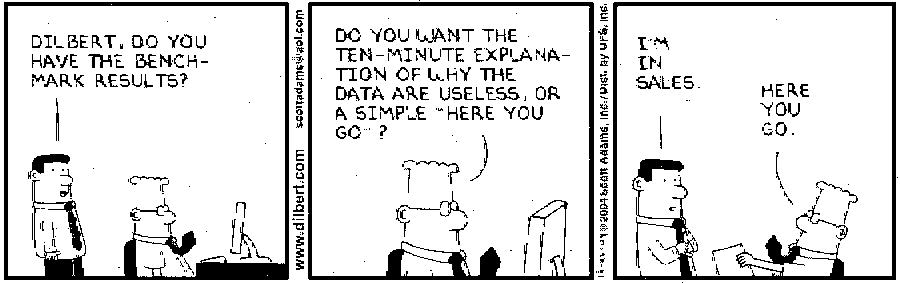

f=0.0001: BER após Hamming(7,4) = 0.012874


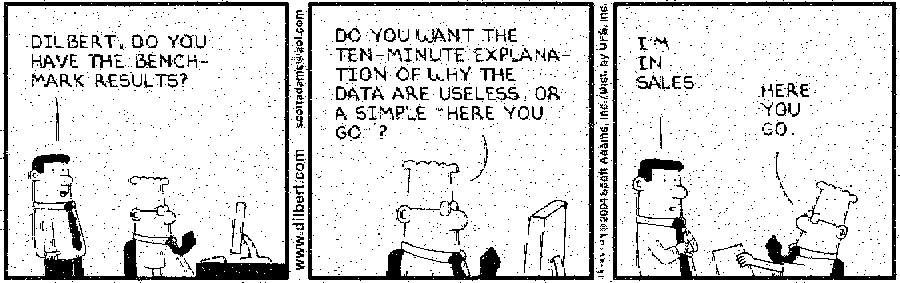

f=0.005: BER após Hamming(7,4) = 0.022038


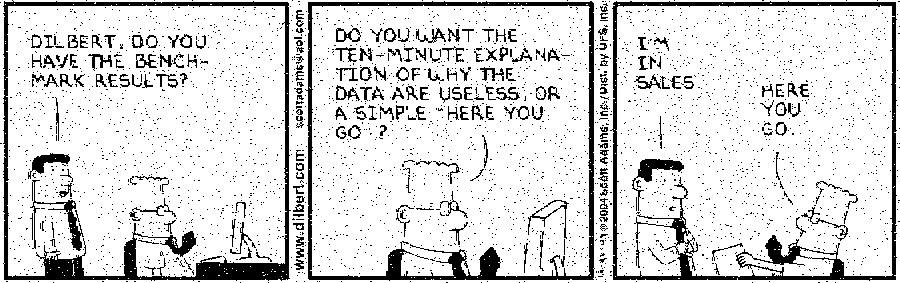

f=0.01: BER após Hamming(7,4) = 0.031217


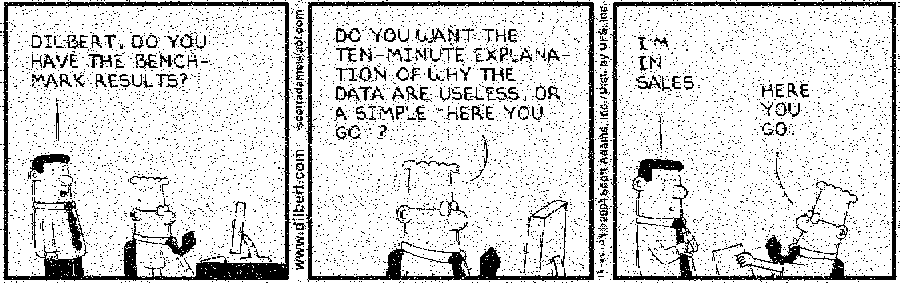

f=0.02: BER após Hamming(7,4) = 0.048528


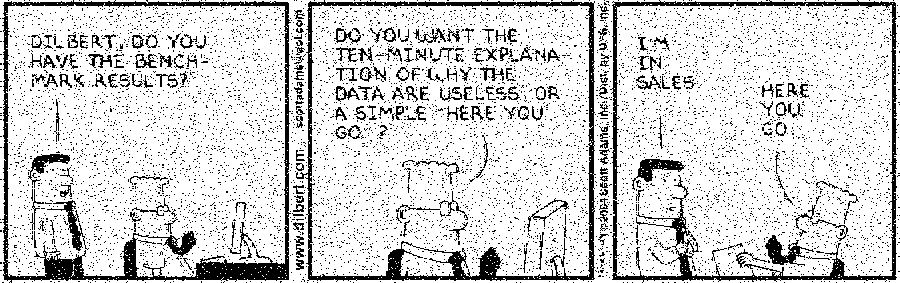

f=0.03: BER após Hamming(7,4) = 0.065120


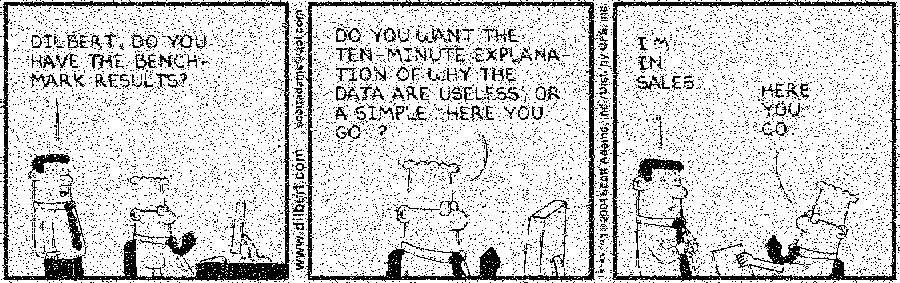

f=0.04: BER após Hamming(7,4) = 0.080750


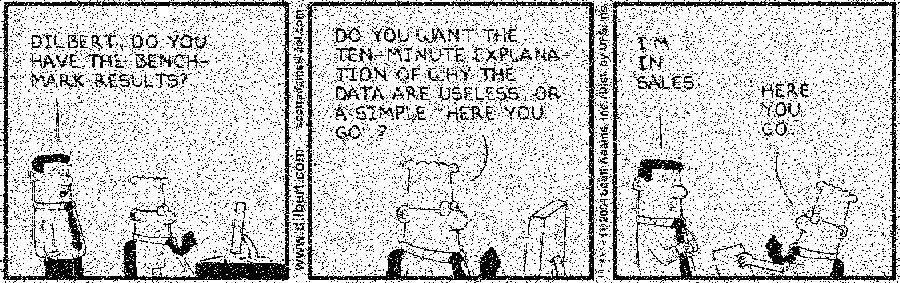

f=0.05: BER após Hamming(7,4) = 0.095677


In [ ]:

h, w = imagem_binaria_01.shape

# sequência binária da imagem (0/1)
bits = imagem_binaria_01.reshape(-1).astype(np.uint8)
n_bits_orig = bits.size

# padding para múltiplos de 4
pad = (4 - (n_bits_orig % 4)) % 4
bits_padded = np.pad(bits, (0, pad), mode='constant')
blocos = bits_padded.reshape(-1, 4)

# Matrizes do código Hamming (7,4)
G = np.array([
    [1, 0, 0, 0, 0, 1, 1],
    [0, 1, 0, 0, 1, 0, 1],
    [0, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 1, 1]
], dtype=np.uint8)

H = np.array([
    [1, 1, 1, 0, 1, 0, 0],
    [1, 0, 1, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 1]
], dtype=np.uint8)

# codificação
codificado = ((blocos @ G) % 2).reshape(-1).astype(np.uint8)

def decode_hamming(bits_rx):
    blocos_rx = bits_rx.reshape(-1, 7).copy()
    decoded = []

    for b in blocos_rx:
        s = np.mod(np.matmul(H, b), 2).astype(np.uint8)
        erro = int(
            np.bitwise_or(
                np.bitwise_or(np.left_shift(s[0], 2), np.left_shift(s[1], 1)),
                s[2]
            )
        )

        if np.logical_and(erro != 0, erro <= 7):
            b[erro - 1] = np.bitwise_xor(b[erro - 1], np.uint8(1))

        decoded.append(b[:4])

    return np.array(decoded, dtype=np.uint8).reshape(-1)

# Valores de f pedidos no enunciado para o Hamming (iv)
f_vals = [0.0001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05]

BER = []
imagens_hamming = []

for f in f_vals:
    rx = canal_ruidoso(codificado, f)
    dec = decode_hamming(rx)[:n_bits_orig]

    ber = calcular_ber(bits, dec)
    BER.append(float(ber))

    img_corr = (dec.reshape(h, w) * 255).astype(np.uint8)
    imagens_hamming.append(img_corr)
    display(Image.fromarray(img_corr))
    print(f'f={f}: BER após Hamming(7,4) = {ber:.6f}')

### v


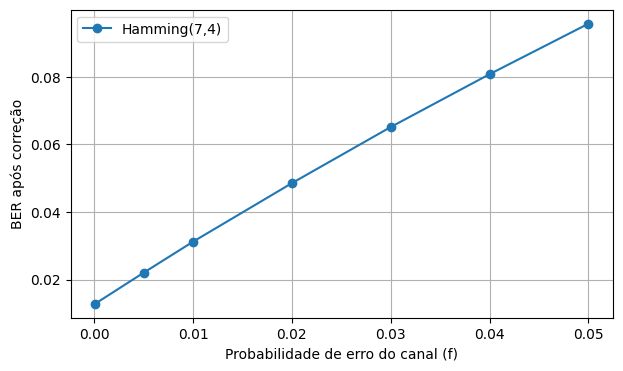

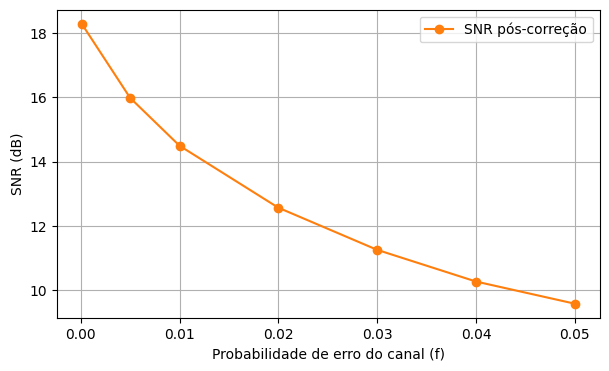

Interpretação: quanto maior o SNR e menor o BER, melhor a correção de erros.


In [ ]:
# Curva BER do Hamming (7,4)
plt.figure(figsize=(7, 4))
plt.plot(f_vals, BER, 'o-', label='Hamming(7,4)')
plt.xlabel('Probabilidade de erro do canal (f)')
plt.ylabel('BER após correção')
plt.grid(True)
plt.legend()
plt.show()

def calcular_snr(original, recuperado):
    ruido = original.astype(np.float64) - recuperado.astype(np.float64)
    Ps = np.mean(original.astype(np.float64) ** 2)
    Pn = np.mean(ruido ** 2)

    if Pn == 0:
        return np.inf
    return 10 * np.log10(Ps / Pn)

# Curva SNR após descodificação Hamming
snr_vals = []

for f in f_vals:
    rx = canal_ruidoso(codificado, f)
    dec = decode_hamming(rx)[:bits.size]
    snr_vals.append(calcular_snr(bits, dec))

plt.figure(figsize=(7, 4))
plt.plot(f_vals, snr_vals, 'o-', color='tab:orange', label='SNR pós-correção')
plt.xlabel('Probabilidade de erro do canal (f)')
plt.ylabel('SNR (dB)')
plt.grid(True)
plt.legend()
plt.show()

print('Interpretação: quanto maior o SNR e menor o BER, melhor a correção de erros.')